# 4bis — Molecular Similarity Analysis

Exploration of chemical-structure similarity across the CSD, based on Morgan fingerprints (radius=2, 2048 bits) precomputed in `molecule_similarity.py`.

Source: `similarity_enriched.csv` — one row per (molecule, neighbor) pair, with `nb_forms` and `identifiers` already joined for both sides.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


In [2]:
# data is only needed for section 1 (InChI column, absent from sim)
data = pd.read_csv("csd_cleaned.csv")
sim  = pd.read_csv("similarity_enriched.csv")
sim

,smiles_1,nb_forms_1,identifiers_1,smiles_2,nb_forms_2,identifiers_2,tanimoto
0,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,Nn1cnnc1NN=Cc1c(Cl)cccc1Cl,1.0,CIJGAD,0.379310
1,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CN(N=Cc1c(Cl)cccc1Cl)C(=O)C1COC(=O)N1C,1.0,HUMJOQ,0.348485
2,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CC(=O)NC1=NN(C(=O)C1=Cc1c(Cl)cccc1Cl)c1ccccc1,1.0,BAKYAP,0.338462
3,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,CN1C=NC(=C1N)C1=NN=CN1NC(C)=O,1.0,TUQBAI,0.327869
4,CC(=O)NN1C=NN=C1N(N=Cc1c(Cl)cccc1Cl)C(C)=O,1.0,AABHTZ,Clc1cccc(Cl)c1C=NNC(=O)c1cnccn1,1.0,HUGDAP,0.322581
...,...,...,...,...,...,...,...
3040315,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,Clc1ccc2SC(=Nc2c1)c1ccccc1,1.0,QEDQIB,0.647059
3040316,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,S1c2ccccc2N=C1C1=Nc2ccccc2S1,1.0,FOCZON|FOCZON01|FOCZON02,0.642857
3040317,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,S1c2ccccc2N=C1c1ccc(cc1)N(c1ccccc1)c1ccccc1,1.0,ZOLREA|ZOLREA01,0.628571
3040318,Clc1ccc(cc1)C1=Nc2ccccc2S1,2.0,ZUYBOM01,FC(F)(F)c1ccc(cc1)C1=Nc2ccccc2S1,1.0,PABWAV,0.628571


### 1. Same molecule, different SMILES string

Fingerprints were deduplicated by SMILES before computing similarity. But the same molecule (same InChI) can appear under multiple SMILES strings in the CSD — those end up as separate entries, each with their own top-10 neighbors.

In [3]:
smiles_per_inchi = data.groupby("inchi")["smiles"].nunique()
split = smiles_per_inchi[smiles_per_inchi > 1]

print(f"Distinct InChI                   : {len(smiles_per_inchi)}")
print(f"  with >1 SMILES string recorded : {len(split)} ({100 * len(split) / len(smiles_per_inchi):.1f}%)")

Distinct InChI                   : 308734
  with >1 SMILES string recorded : 235 (0.1%)


In [4]:
# Example: same InChI, two different SMILES
data[data["inchi"].isin(split.index)][["inchi", "smiles"]]\
    .drop_duplicates()\
    .sort_values("inchi")\
    .head(20)

,inchi,smiles
205326,InChI=1S/2C10H10N2O/c2*1-7-9(11-12-10(7)13)8-5...,CC1=C(NNC1=O)c1ccccc1.CC1=C(NNC1=O)c1ccccc1
216058,InChI=1S/2C10H10N2O/c2*1-7-9(11-12-10(7)13)8-5...,CC1=C(NN=C1O)c1ccccc1.CC1=C(NN=C1O)c1ccccc1
198552,InChI=1S/2C10H10N2O/c2*1-8-7-10(13)12(11-8)9-5...,CC1=CC(=O)N(N1)c1ccccc1.CC1=NN(C(=C1)O)c1ccccc1
189120,InChI=1S/2C10H10N2O/c2*1-8-7-10(13)12(11-8)9-5...,CC1=NN(C(=C1)O)c1ccccc1.CC1=CC(=O)N(N1)c1ccccc1
73809,InChI=1S/2C10H13N5O4/c2*1-5-3-15(10(18)12-9(5)...,CC1=CN(C2CC([N-][N+]#N)C(CO)O2)C(=O)NC1=O.CC1=...
73804,InChI=1S/2C10H13N5O4/c2*1-5-3-15(10(18)12-9(5)...,CC1=CN(C2CC(N=[N+]=[N-])C(CO)O2)C(=O)NC1=O.CC1...
17721,InChI=1S/2C11H11N3O2S/c2*12-9-4-6-10(7-5-9)17(...,Nc1ccc(cc1)S(=O)(=O)N=C1NC=CC=C1.Nc1ccc(cc1)S(...
17720,InChI=1S/2C11H11N3O2S/c2*12-9-4-6-10(7-5-9)17(...,Nc1ccc(cc1)S(=O)(=O)N=C1NC=CC=C1.Nc1ccc(cc1)S(...
38780,InChI=1S/2C12H32N5O4P3/c2*1-5-9-18-22(13)15-23...,CCCOP1(=NP(=NP(=N1)(OCCC)OCCC)(N)OCCC)N.CCCOP1...
38779,InChI=1S/2C12H32N5O4P3/c2*1-5-9-18-22(13)15-23...,CCCOP1(=NP(=NP(=N1)(N)OCCC)(OCCC)OCCC)N.CCCOP1...


Sanity check: by construction (`molecule_similarity.py` deduplicates on unique SMILES and excludes self-matches), `smiles_1` and `smiles_2` should never be equal. Among pairs with `tanimoto == 1`, we also check whether the two SMILES resolve to the same InChI.

In [5]:
exact = sim[sim["tanimoto"] == 1]
print(f"Pairs with tanimoto == 1       : {len(exact)}")
print(f"  smiles_1 == smiles_2         : {(exact['smiles_1'] == exact['smiles_2']).sum()}")

Pairs with tanimoto == 1       : 9736
  smiles_1 == smiles_2         : 0


In [6]:
smiles_to_inchi = data.drop_duplicates("smiles").set_index("smiles")["inchi"]
inchi_1 = exact["smiles_1"].map(smiles_to_inchi)
inchi_2 = exact["smiles_2"].map(smiles_to_inchi)
same_inchi = (inchi_1 == inchi_2).sum()

print(f"  same InChI (duplicate SMILES of same molecule) : {same_inchi} ({100*same_inchi/len(exact):.1f}%)")
print(f"  different InChI (true fingerprint collision)   : {len(exact)-same_inchi} ({100*(1-same_inchi/len(exact)):.1f}%)")

  same InChI (duplicate SMILES of same molecule) : 124 (1.3%)
  different InChI (true fingerprint collision)   : 9612 (98.7%)


### 2. Polymorphism vs. chemical neighborhood

For each polymorphic molecule, how many of its 10 nearest chemical neighbors are also polymorphic?

In [7]:
sim["poly_neighbor"] = sim["nb_forms_2"] > 1

# One row per polymorphic molecule: neighbor count + best similarity
poly = sim[sim["nb_forms_1"] > 1]
stats = poly.groupby("smiles_1").agg(
    n_poly_neighbors=("poly_neighbor", "sum"),
    best_sim=("tanimoto", "max"),
    num_forms=("nb_forms_1", "first"),
)

base_rate = sim.drop_duplicates("smiles_1")["nb_forms_1"].gt(1).mean()
isolated  = stats[stats["n_poly_neighbors"] == 0]

print(f"Polymorphic molecules               : {len(stats)}")
print(f"  with 0 polymorphic neighbors      : {len(isolated)} ({100*len(isolated)/len(stats):.1f}%)")
print(f"  expected if random neighborhood   : {100*(1-base_rate)**10:.1f}%")

Polymorphic molecules               : 5409
  with 0 polymorphic neighbors      : 2465 (45.6%)
  expected if random neighborhood   : 83.6%


Isolated polymorphic molecules — sorted by number of crystal forms (most studied first):

In [8]:
isolated.sort_values("num_forms", ascending=False).head(20)

,n_poly_neighbors,best_sim,num_forms
smiles_1,,,
O=C1Cc2ccccc2N1,0,0.695652,9.0
Cc1cccc(n1)C1=NN2CCCC2=C1c1ccnc2ccc(cc12)C(N)=O,0,0.312500,9.0
NC(=O)c1cccnc1,0,0.680000,9.0
Clc1ccc(CN2CCNC2=NN(=O)=O)cn1,0,0.640000,7.0
CC(=NNC(=O)c1ccncc1)c1ccccc1,0,0.750000,7.0
COc1cc(OC)c2C(=O)C3(Oc2c1Cl)C(C)CC(=O)C=C3OC,0,0.820000,6.0
O=C1N(CCCCCCN2c3ccccc3Sc3ccccc23)C(=O)c2cccc3cccc1c23,0,0.789474,6.0
CC(C)N1C(=O)NC(=CC1=O)NC(C)c1ccccc1,0,0.413043,5.0
NC(=O)C1=NN(C=N1)C1OC(CO)C(O)C1O,0,0.687500,5.0


Zoom on the most isolated molecule: its full top-10 neighborhood, to understand why none of its neighbors are polymorphic.

In [9]:
first = isolated.sort_values("num_forms", ascending=False).index[0]
print(f"SMILES      : {first}")
print(f"Identifiers : {sim[sim['smiles_1']==first]['identifiers_1'].iloc[0]}")

sim[sim["smiles_1"] == first]\
    .sort_values("tanimoto", ascending=False)\
    [["smiles_2", "nb_forms_2", "poly_neighbor", "tanimoto", "identifiers_2"]]

SMILES      : O=C1Cc2ccccc2N1
Identifiers : ZOYLII13|ZOYLII14|ZOYLII16|ZOYLII17|ZOYLII18|ZOYLII19|ZOYLII20


,smiles_2,nb_forms_2,poly_neighbor,tanimoto,identifiers_2
2963790,O=C1CC(=O)Nc2ccccc2N1,1.0,False,0.695652,CENRUJ
2963791,COc1cc2CC(=O)Nc3ccccc3Cc2cc1OC,1.0,False,0.656250,HIGPEW
2963792,O=C1CCc2ccccc2N1,1.0,False,0.653846,BOSLAX|BOSLAX01|BOSLAX02
2963793,C1c2ccccc2Nc2ccccc12,1.0,False,0.652174,JOSLOU|JOSLOU01
2963794,O=C1CCCCc2ccccc2N1,1.0,False,0.607143,SUVCUJ
2963795,O=C1Nc2ccccc2Cc2ccccc12,1.0,False,0.586207,IDOSAW|IDOSAW01
2963796,O=C1Cc2ccccc2C(=O)N1,NaN,False,0.571429,NaN
2963797,O=C1CCC(=O)Nc2ccccc2N1,1.0,False,0.560000,MUXJEX
2963798,O=C1Cc2cc3c(Cc4ccccc34)cc2N1,1.0,False,0.545455,JIGMOF
2963799,Clc1ccc2CC(=O)Nc2c1,1.0,False,0.533333,YADLIA


Distribution of polymorphic-neighbor counts across all polymorphic molecules, then the ones most surrounded by other polymorphs (≥ 9/10 neighbors polymorphic):

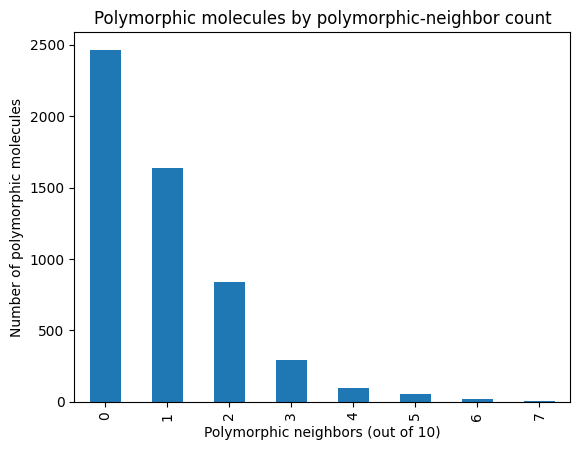

In [10]:
stats["n_poly_neighbors"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Polymorphic neighbors (out of 10)")
plt.ylabel("Number of polymorphic molecules")
plt.title("Polymorphic molecules by polymorphic-neighbor count")
plt.show()

In [11]:
stats[stats["n_poly_neighbors"] >= 9].sort_values("n_poly_neighbors", ascending=False)

,n_poly_neighbors,best_sim,num_forms
smiles_1,,,


Zoom on one of the most embedded molecules — its best neighbor has `tanimoto == 1`, worth checking whether it is a genuinely distinct structure or a near-duplicate SMILES.

In [13]:
candidates_9 = stats[stats["n_poly_neighbors"] >= 9].sort_values("n_poly_neighbors", ascending=False)

if candidates_9.empty:
    print("No polymorphic molecule with >=9/10 polymorphic neighbors.")
else:
    target = candidates_9.index[0]
    print(f"SMILES      : {target}")
    print(f"Identifiers : {sim[sim['smiles_1']==target]['identifiers_1'].iloc[0]}")

    display(
        sim[sim["smiles_1"] == target]
        .sort_values("tanimoto", ascending=False)
        [["smiles_2", "nb_forms_2", "poly_neighbor", "tanimoto", "identifiers_2"]]
    )

No polymorphic molecule with >=9/10 polymorphic neighbors.


### 3. Monomorphic molecules with a polymorphic look-alike

Among molecules recorded as monomorphic, which ones have a structurally very similar polymorphic neighbor? These are candidates that may actually be polymorphic but understudied.

In [14]:
mono = sim[sim["nb_forms_1"] == 1]

# Best polymorphic neighbor per monomorphic molecule
best_poly_neighbor = (
    mono[mono["poly_neighbor"]]
    .sort_values("tanimoto", ascending=False)
    .groupby("smiles_1").first()
)

n_mono = sim["smiles_1"].nunique() - len(stats)
print(f"Monomorphic molecules                    : {n_mono}")
print(f"  with >=1 polymorphic neighbor in top10 : {len(best_poly_neighbor)} ({100*len(best_poly_neighbor)/n_mono:.1f}%)")

Monomorphic molecules                    : 298623
  with >=1 polymorphic neighbor in top10 : 65552 (22.0%)


In [15]:
candidates = best_poly_neighbor[best_poly_neighbor["tanimoto"] >= 0.9]\
    .sort_values("tanimoto", ascending=False).copy()

# smiles_to_inchi defined in section 1 — use it to identify true duplicates
candidates["inchi_1"] = candidates.index.map(smiles_to_inchi)
candidates["inchi_2"] = candidates["smiles_2"].map(smiles_to_inchi)
same_mol = candidates["inchi_1"] == candidates["inchi_2"]

print(f"Candidates (tanimoto >= 0.9 to a known polymorph) : {len(candidates)}")
print(f"  same molecule (same InChI)                      : {same_mol.sum()} — not a real signal")
print(f"  genuine look-alikes (different InChI)           : {(~same_mol).sum()}")

candidates[~same_mol][["smiles_2", "nb_forms_2", "identifiers_2", "tanimoto"]].head(20)

Candidates (tanimoto >= 0.9 to a known polymorph) : 544
  same molecule (same InChI)                      : 0 — not a real signal
  genuine look-alikes (different InChI)           : 544


,smiles_2,nb_forms_2,identifiers_2,tanimoto
smiles_1,,,,
C(=CC=CC=Cc1ccccc1)C=CC=Cc1ccccc1,C(=CC=Cc1ccccc1)C=Cc1ccccc1,3.0,KUXZAF|ZZZQNK02|ZZZQNK04|ZZZQNK05|ZZZQNK06|ZZZ...,1.0
c1ccc(cc1)P1(=NP(=NP(=NP(=N1)(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1)(c1ccccc1)c1ccccc1)c1ccccc1,c1ccc(cc1)P1(=NP(=NP(=N1)(c1ccccc1)c1ccccc1)(c...,2.0,HPCYPN|HPCYPN01,1.0
[NH3+]CCCCCCCC(=O)[O-],[NH3+]CCCCCC(=O)[O-],2.0,AMCAPR01|AMCAPR10|AMCAPR11,1.0
c1cc2ccc3ccc4ccc5ccc6ccc7ccc1c1c2c3c4c5c6c71,c1cc2ccc3ccc4ccc5ccc6ccc1c1c2c3c4c5c61,4.0,CORONE02|CORONE03|CORONE04|CORONE05|CORONE06|C...,1.0
S1C=Cc2c1ccc1Sc3ccc4Sc5ccc6Sc7ccc8SC=Cc8c7c6c5c4c3c21,c1cc2c(ccc3sc4ccc5sc6ccc7sccc7c6c5c4c23)s1,2.0,DESWAZ|DESWED,1.0
S1N=C2C=Cc3ccc4ccc5ccc6ccc7C=CC8=NSN=C8c7c6c5c4c3C2=N1,S1N=C2C=Cc3ccc4ccc5ccc6C=CC7=NSN=C7c6c5c4c3C2=N1,2.0,TILGUU|TILGUU02,1.0
S1SSSc2ccccc2SSS1,S1SSc2ccccc2SS1,2.0,BZPTHP,1.0
Oc1ccccc1C=NCCCCCCN=Cc1ccccc1O,Oc1ccccc1C=NCCCCCCCCCCN=Cc1ccccc1O,2.0,CEJREP|CEJREP01,1.0
Oc1ccccc1C=NCCCCCN=Cc1ccccc1O,Oc1ccccc1C=NCCCCCCCCCCN=Cc1ccccc1O,2.0,CEJREP|CEJREP01,1.0


Refinement: among genuine look-alikes (different InChI, tanimoto ≥ 0.9), count how many independent polymorphic neighbors each monomorphic molecule has. Two or more is a much stronger signal than one.

In [16]:
# All genuine close polymorphic neighbors (tanimoto >= 0.9, different InChI)
close = mono[mono["poly_neighbor"] & (mono["tanimoto"] >= 0.9)].copy()
close["same_mol"] = (
    close["smiles_1"].map(smiles_to_inchi) == close["smiles_2"].map(smiles_to_inchi)
)
close = close[~close["same_mol"]]

refined = (
    close.groupby("smiles_1")
    .agg(
        n_close_poly=("tanimoto", "count"),
        best_sim=("tanimoto", "max"),
        identifiers=("identifiers_1", "first"),
    )
    .sort_values(["n_close_poly", "best_sim"], ascending=False)
)

print(f"Monomorphic with >=1 genuine close polymorphic neighbor : {len(refined)}")
print(f"  of which >=4                                         : {(refined['n_close_poly'] >= 4).sum()}")

refined[refined["n_close_poly"] >= 4]

Monomorphic with >=1 genuine close polymorphic neighbor : 544
  of which >=4                                         : 23


,n_close_poly,best_sim,identifiers
smiles_1,,,
CCCCCCCCCCC(O)=O,8,1.000000,ZZZNYY01
CCCCCCCCCCCCCC(O)=O,8,1.000000,ZZZOEG02
CCCCCCC(O)=O,6,1.000000,ISENOJ
CCCCCCCC(O)=O,6,1.000000,ISENUP
CCCCCCCCC(O)=O,6,1.000000,ISEPAX
CCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCCCCCCC)OC(=O)CCCCCCCC=CCCCCCCCC,6,1.000000,QESHUS
CCCCCCCCCCCCCCCCCC(=O)OCC(COC(=O)CCCCCCCC=CCCCCCCCC)OC(=O)CCCCCCCCCCCCCCCCC,6,1.000000,HISREH
OCCCCCCCCCCCCCCO,6,1.000000,CAVDEI
CCCCCCCCCCCCCCCC(O)=O,5,1.000000,YEFWEM01


Same-molecule cases (same InChI, different SMILES string): confirming these are recording artefacts, not genuine polymorphic look-alikes.

In [17]:
candidates[same_mol][["smiles_2", "nb_forms_2", "identifiers_2", "tanimoto"]].head(10)

,smiles_2,nb_forms_2,identifiers_2,tanimoto
smiles_1,,,,


### 4. Monomorphic molecules fully surrounded by polymorphs

Symmetric of the 'isolated' analysis in section 2: distribution of polymorphic-neighbor counts for monomorphic molecules, and zoom on those with ≥ 9/10 polymorphic neighbors — the strongest structural candidates for undetected polymorphism.

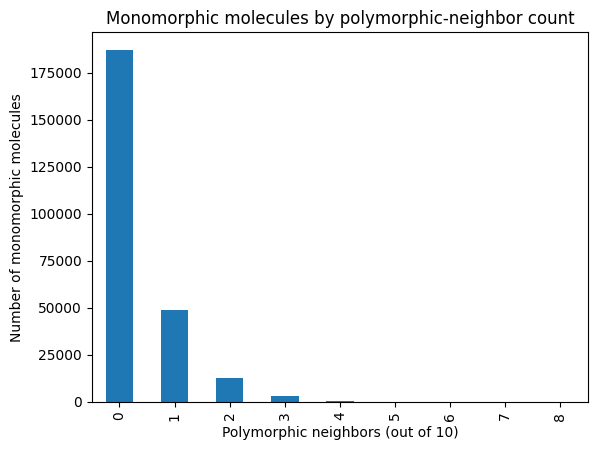

Monomorphic molecules with >=9 polymorphic neighbors: 0


,n_poly_neighbors,best_sim
smiles_1,,


In [18]:
mono_stats = (
    sim[sim["nb_forms_1"] == 1]
    .groupby("smiles_1")
    .agg(
        n_poly_neighbors=("poly_neighbor", "sum"),
        best_sim=("tanimoto", "max"),
    )
)

mono_stats["n_poly_neighbors"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Polymorphic neighbors (out of 10)")
plt.ylabel("Number of monomorphic molecules")
plt.title("Monomorphic molecules by polymorphic-neighbor count")
plt.show()

high = mono_stats[mono_stats["n_poly_neighbors"] >= 9].sort_values("n_poly_neighbors", ascending=False)
print(f"Monomorphic molecules with >=9 polymorphic neighbors: {len(high)}")
high

Zoom on the most surrounded one — its full neighborhood:

In [19]:
target_mono = high.index[0]
print(f"SMILES      : {target_mono}")
print(f"Identifiers : {sim[sim['smiles_1']==target_mono]['identifiers_1'].iloc[0]}")

sim[sim["smiles_1"] == target_mono]\
    .sort_values("tanimoto", ascending=False)\
    [["smiles_2", "nb_forms_2", "tanimoto", "identifiers_2"]]

IndexError: index 0 is out of bounds for axis 0 with size 0